##Libs-importation

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##Data-importation

Le fichier ne contient que les enregistrements où le coût est différent de 0. Si une combinaison (EID,
MONTH, PEAKID) est absente, alors le coût est considéré égal à 0 pour cette opportunité.

In [3]:
df_cost = pd.read_parquet('/content/costs.parquet') #2020-2023
df_prices = pd.read_parquet('/content/prices.parquet')

In [4]:
df_prices.head()

,EID,DATETIME,PEAKID,PRICEREALIZED
0,2,2020-12-17 04:00:00,0,-6.1668
1,2,2020-12-17 05:00:00,0,-8.0481
2,2,2020-12-17 07:00:00,1,-6.6012
3,2,2020-12-17 08:00:00,1,-7.1004
4,2,2020-12-18 18:00:00,1,-1.8222


In [5]:
df_cost.head()

,EID,MONTH,PEAKID,C
0,3,2020-08,0,18.839701
1,3,2020-09,0,15.829500
2,3,2020-10,0,67.694901
3,3,2020-10,1,1.245600
4,3,2020-12,0,66.708801


EID Identifiant unique de l’élément du réseau.

DATETIME Horodatage au format ISO 8601 sans timezone (ex. 2022-06-15 14 :00 :00), résolution horaire

MONTH Mois au format YYYY-MM (ex. 2022-06)

PEAKID Profil horaire : 0 = OFF (Off-Peak), 1 = ON (On-Peak)

In [6]:
df_cost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9092 entries, 0 to 9091
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EID     9092 non-null   int16  
 1   MONTH   9092 non-null   object 
 2   PEAKID  9092 non-null   int8   
 3   C       9092 non-null   float32
dtypes: float32(1), int16(1), int8(1), object(1)
memory usage: 133.3+ KB


In [7]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453167 entries, 0 to 453166
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   EID            453167 non-null  int16         
 1   DATETIME       453167 non-null  datetime64[ns]
 2   PEAKID         453167 non-null  int8          
 3   PRICEREALIZED  453167 non-null  float32       
dtypes: datetime64[ns](1), float32(1), int16(1), int8(1)
memory usage: 6.5 MB


##EDA

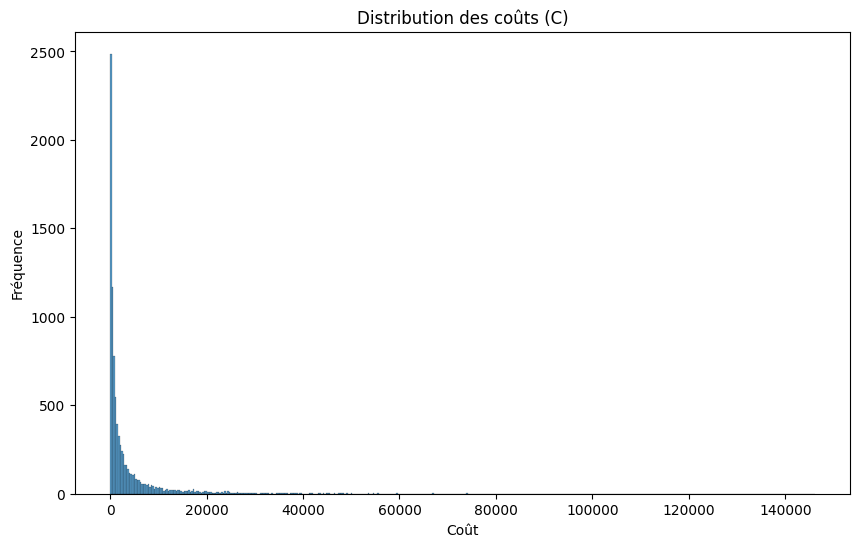

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cost['C'])
plt.title('Distribution des coûts (C)')
plt.xlabel('Coût')
plt.ylabel('Fréquence')
plt.show()

<Axes: ylabel='Count'>

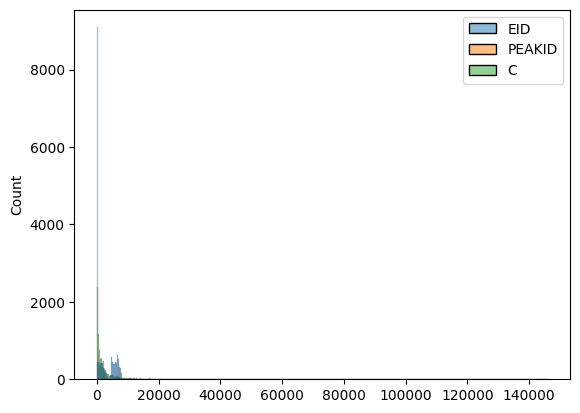

In [9]:
sns.histplot(df_cost)

In [10]:
df_cost.groupby("EID")["C"].mean().sort_values(ascending=False).head(10)

,C
EID,
3189,50166.640625
5832,45078.789062
1952,43796.066406
7020,39371.417969
7258,37858.878906
1225,36512.847656
3035,35880.773438
2188,35480.621094
6817,30180.369141


**Observations :
certains éléments du réseau sont plus chers :
variations significatives dans les coûts moyens entre les différents EIDs
Cela signifie probablement qu ils correspondent à des zones du réseau plus congestionnées
ou juste bcp plus importants**

In [11]:
df_cost.groupby("PEAKID")["C"].mean()
#coût ON vs OFF peak

,C
PEAKID,
0,4222.460449
1,3845.253418


In [12]:
df_cost.groupby("MONTH")["C"].mean()
#saisonnalité possible.

,C
MONTH,
2020-01,2480.335449
2020-02,1631.634155
2020-03,1965.757446
2020-04,2331.000488
2020-05,1657.066284
2020-06,1427.715576
2020-07,1725.960938
2020-08,1618.936890
2020-09,2095.640381


##Metrics-calcus

###1/Profit

Au moment de la décision (cutoff = 7 du mois M), l’historique complet des coûts (C) est disponible
jusqu’au mois M inclus.
Le coût du mois M+1 n’est pas encore disponible au cutoff et ne doit pas être utilisé.

Obj : realiser le meme dataset que cost , l objectif est d avoir une sortie similaire pour les MOIS futurs , l objectif est de cree un triplet ( EID , MONTH , PEAKID) qui s appelle OPPORTUNITE et elle doit etre profitable avec le critere page 4 doumentation 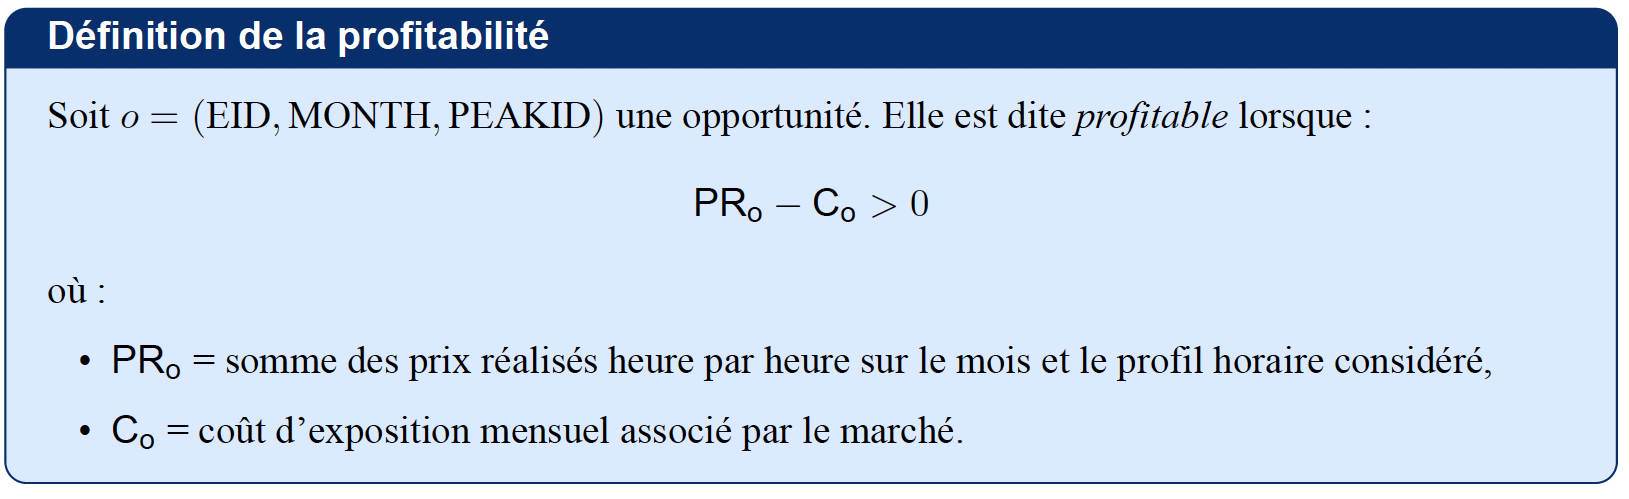

In [13]:
df_prices["MONTH"] = df_prices["DATETIME"].dt.strftime("%Y-%m")

# PR observé
PR = (df_prices.groupby(["EID", "MONTH", "PEAKID"], as_index=False)["PRICEREALIZED"].sum().rename(columns={"PRICEREALIZED": "PR"}))

# Univers complet des opportunités Parce que certains EID apparaissent seulement dans cost ou seulement dans prices.
all_eids = pd.Index(sorted(set(df_cost["EID"]).union(set(df_prices["EID"]))), name="EID")
all_months = pd.Index(sorted(set(df_cost["MONTH"]).union(set(df_prices["MONTH"]))), name="MONTH")
all_peakids = pd.Index([0, 1], name="PEAKID")
full_index = pd.MultiIndex.from_product([all_eids, all_months, all_peakids],names=["EID", "MONTH", "PEAKID"])

opportunities = full_index.to_frame(index=False)

df_profit = opportunities.merge(PR, on=["EID", "MONTH", "PEAKID"], how="left")
df_profit = df_profit.merge(df_cost, on=["EID", "MONTH", "PEAKID"], how="left")

df_profit["PR"] = df_profit["PR"].fillna(0)
df_profit["C"] = df_profit["C"].fillna(0)


In [14]:
#Profit
df_profit["PROFIT"] = df_profit["PR"] - df_profit["C"]

# Taux d'opportunités profitables juste pour verifier avec enoncé et pas avoir fait de betises
rate = (df_profit["PROFIT"] > 0).mean()
print(rate)

0.015144205350533997


Après reconstruction de l’univers complet des opportunités (EID, MONTH, PEAKID) et imputation des absences par 0 conformément à la documentation, environ 1.5 % des opportunités sont profitables. ce qui confirme que le problème est fortement **déséquilibré**

1. prédire PR (prix futur)
2. comparer avec C
3. sélectionner les meilleurs trades

In [15]:
df_profit.groupby("EID")["C"].mean().sort_values(ascending=False).head(10)

,C
EID,
1599,17156.412109
5662,14907.708984
301,14022.163086
3035,13912.953125
6015,11785.649414
230,10120.872070
1944,9804.271484
5152,7982.433594
2229,7738.833496


In [16]:
profit_mean = df_profit.groupby("EID")["PROFIT"].mean().sort_values(ascending=False)
(profit_mean < 0).sum()


np.int64(2227)

In [17]:
(profit_mean > 0).sum()

np.int64(861)

###2/Search for occasions on 1.5%

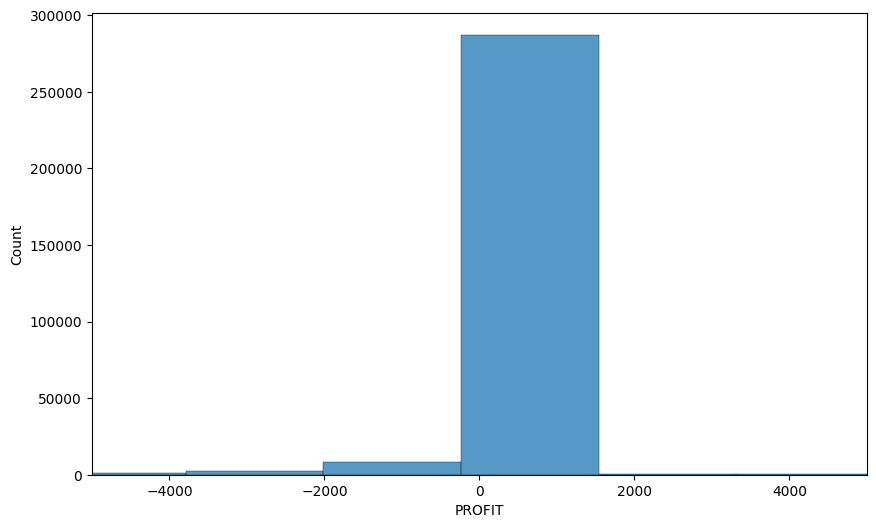

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df_profit["PROFIT"], bins=200)
plt.xlim(-5000,5000)
plt.show()

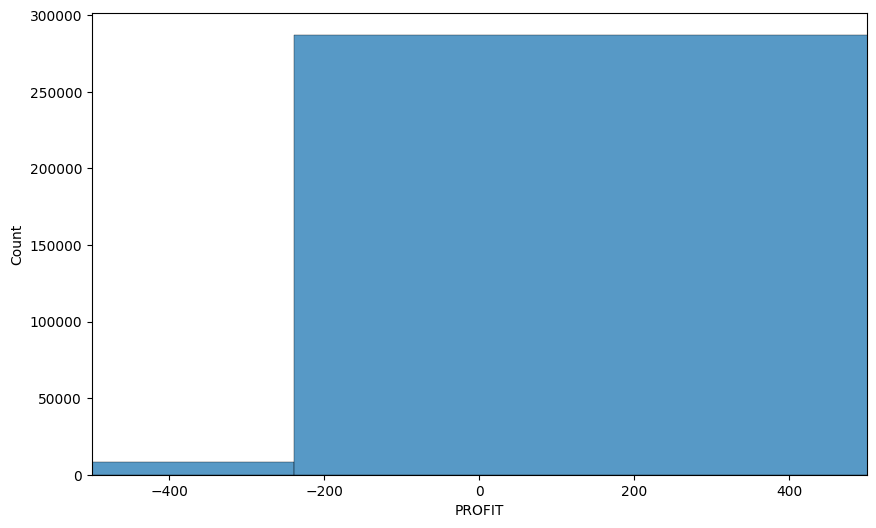

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df_profit["PROFIT"], bins=200)
plt.xlim(-500,500)
plt.show()

**Observation** :


*   beaucoup de petits profits/pertes
*   quelques profits très grands


**obj** : Identifier les rares événements extrêmes

La distribution du profit est fortement concentrée autour de zéro . La majorité des opportunités génèrent un profit nul tandis que quelques rares produisent des gains/pertes extrêmes. Cette distribution asymétrique confirme que le problème consiste principalement à **identifier un petit nombre d'opportunités** très profitables.

In [20]:
profit_par_eid = df_profit.groupby("EID")["PROFIT"].sum().sort_values(ascending=False)
profit_par_eid.head(20)

,PROFIT
EID,
6378,565741.500000
6986,157179.546875
7679,153228.531250
6157,152784.937500
6585,104126.703125
5611,102455.320312
6360,88332.328125
6246,68643.671875
7419,68068.789062


In [21]:
df_profit["PROFIT"].quantile([0.01,0.05,0.5,0.95,0.99])
#1 % des opportunités ≤ -6099 certaines décisions peuvent être très dangereuses.

,PROFIT
0.01,-6099.940894
0.05,-212.386691
0.50,0.000000
0.95,0.000000
0.99,86.683006


**modèle doit :
éviter pertes,avant de chercher les profits.
precision > recall**

In [22]:
eid_profit = df_profit.groupby("EID")["PROFIT"].sum().sort_values(ascending=False)

eid_profit.head(20)

,PROFIT
EID,
6378,565741.500000
6986,157179.546875
7679,153228.531250
6157,152784.937500
6585,104126.703125
5611,102455.320312
6360,88332.328125
6246,68643.671875
7419,68068.789062


L’EID 6378 génère plus de 3 fois le profit du deuxième.*texte en italique*

In [23]:
df_profit.groupby("EID").size().sort_values(ascending=False).head(20)

,0
EID,
8191,98
8190,98
8189,98
8187,98
8186,98
8185,98
8184,98
8183,98
8182,98


In [24]:
df_profit.groupby("EID")["PROFIT"].sum().sort_values(ascending=False).head(20)

,PROFIT
EID,
6378,565741.500000
6986,157179.546875
7679,153228.531250
6157,152784.937500
6585,104126.703125
5611,102455.320312
6360,88332.328125
6246,68643.671875
7419,68068.789062


Donc les EID en haut du tableau sont vraiment les plus rentables.

Ce n’est pas un biais dû à un nombre d’observations plus élevé.

Cela correspond très bien à la réalité des réseaux électriques :

certaines lignes

certains nœuds

sont souvent congestionnés.

EID
+
historique de profit
+
structure temporelle

In [25]:
df_profit[df_profit["EID"] == 6378].sort_values("PROFIT", ascending=False).head(10)

,EID,MONTH,PEAKID,PR,C,PROFIT
138545,6378,2022-12,1,32751.673828,0.0,32751.673828
138498,6378,2021-01,0,27812.699219,0.0,27812.699219
138533,6378,2022-06,1,26290.371094,0.0,26290.371094
138499,6378,2021-01,1,24949.492188,0.0,24949.492188
138544,6378,2022-12,0,22934.464844,0.0,22934.464844
138524,6378,2022-02,0,21318.667969,0.0,21318.667969
138536,6378,2022-08,0,18500.033203,0.0,18500.033203
138525,6378,2022-02,1,17040.353516,0.0,17040.353516
138522,6378,2022-01,0,16882.212891,0.0,16882.212891
138532,6378,2022-06,0,16518.457031,0.0,16518.457031


L’analyse des plus gros profits de l’EID 6378 montre que ses opportunités les plus rentables surviennent lors de quelques mois spécifiques, notamment janvier 2021, février 2022, juin 2022 et décembre 2022. Dans ces cas, le coût d’exposition est nul, ce qui fait que le profit correspond directement au prix réalisé. L’EID 6378 semble donc associé à des épisodes particuliers du réseau où des prix réalisés élevés génèrent des gains importants, à la fois en On-Peak et en Off-Peak.

In [26]:
df_profit.groupby("PEAKID")["PROFIT"].agg([
    "mean",
    "median",
    "std",
    "max",
    "min"
])#L’analyse du profit par profil horaire montre que les opportunités On-Peak et Off-Peak présentent toutes deux une médiane nulle et une moyenne négative, ce qui confirme que la majorité des opportunités ne sont pas rentables. Le profil On-Peak apparaît légèrement moins défavorable en moyenne, tandis que le profil Off-Peak présente une dispersion un peu plus élevée et le gain maximal le plus important. À l’inverse, la perte extrême la plus importante est observée en On-Peak.

,mean,median,std,max,min
PEAKID,,,,,
0,-270.772614,0.0,3520.546875,81473.679688,-263788.03125
1,-261.547333,0.0,3182.605957,60158.777344,-273797.37500


<Axes: xlabel='MONTH'>

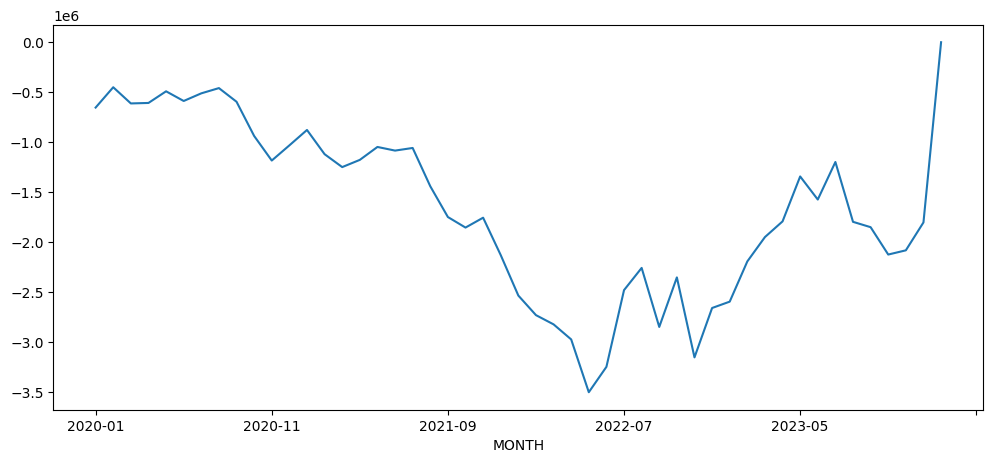

In [27]:
df_profit.groupby("MONTH")["PROFIT"].sum().plot(figsize=(12,5)) #Regarde plutôt le profit total par mois :

L’évolution temporelle du profit moyen par mois montre une tendance globalement négative sur l’ensemble de la période. Une phase particulièrement défavorable est observée entre fin 2021 et mi-2022, où les pertes moyennes sont les plus importantes. Une amélioration progressive apparaît ensuite à partir de 2023. Ces variations suggèrent que les conditions du marché électrique évoluent dans le temps et qu’un modèle prédictif devra tenir compte de cette dimension temporelle

hiver → congestion réseau → plus d'opportunités
été → marché stable → moins d'opportunités

In [28]:
(df_profit.groupby("MONTH")["PROFIT"].apply(lambda x: (x > 0).mean()))

,PROFIT
MONTH,
2020-01,0.008905
2020-02,0.009391
2020-03,0.010039
2020-04,0.013439
2020-05,0.012791
2020-06,0.015382
2020-07,0.010848
2020-08,0.013115
2020-09,0.018459


1 % à 2 % des opportunités sont profitables selon les mois
certains **mois** du réseau produisent plus d'opportunités :  **périodes de congestion**

In [29]:
pivot_sum = df_profit.pivot_table(
    values="PROFIT",
    index="EID",
    columns="PEAKID",
    aggfunc="sum"
)

<Axes: xlabel='PEAKID', ylabel='EID'>

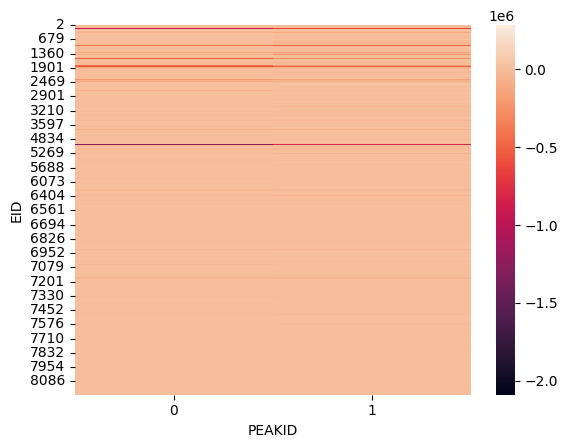

In [30]:
sns.heatmap(pivot_sum)

<Axes: xlabel='MONTH', ylabel='EID'>

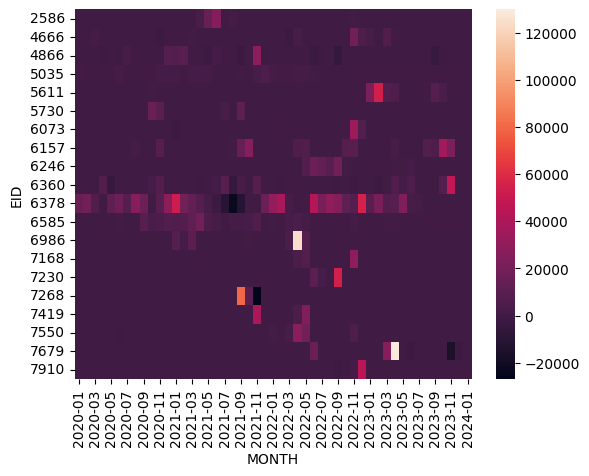

In [31]:
top_eids = df_profit.groupby("EID")["PROFIT"].sum().nlargest(20).index
pivot = df_profit[df_profit["EID"].isin(top_eids)].pivot_table(values="PROFIT",index="EID",columns="MONTH",aggfunc="sum")
sns.heatmap(pivot)

on voit des pics pour :

6378

6986

7268

7679

Donc certains EID ont des événements très rentables mais très ponctuels.

il ya des périodes où plusieurs EID deviennent profitables en même temps.
le profit dépend fortement du moment
et du nœud du réseau

**détecter les événements de congestion**

La heatmap des profits par EID et par mois révèle que les opportunités profitables apparaissent sous forme d’événements ponctuels et localisés. La majorité des combinaisons EID–mois ne génèrent aucun profit, tandis que quelques EID présentent des pics importants à des moments spécifiques. Cela suggère que la rentabilité est fortement liée à des événements rares de congestion du réseau plutôt qu’à un comportement moyen constant.

In [91]:
profit_by_eid = df_profit.groupby("EID")["PROFIT"].sum().sort_values(ascending=False)
profit_by_eid.cumsum() / profit_by_eid.sum()

,PROFIT
EID,
6378,-0.007024
6986,-0.008975
7679,-0.010878
6157,-0.012774
6585,-0.014067
...,...
3035,0.853294
1944,0.887350
301,0.921723


À ce stade  EDA a identifié  4 caractéristiques principales du problème :

Rareté des opportunités profitables (~1.5%)
Forte concentration du profit sur certains EID
Dépendance temporelle importante (MONTH)
Influence du profil horaire (PEAKID)

##modelistation pipeline

In [92]:
df_profit["TARGET"] = (df_profit["PROFIT"] > 0).astype(int)
df_profit["profit_last_month"] = (
    df_profit.sort_values("MONTH")
    .groupby(["EID","PEAKID"])["PROFIT"]
    .shift(1)
)
df_profit["profit_mean_3m"] = (
    df_profit.sort_values("MONTH")
    .groupby(["EID","PEAKID"])["PROFIT"]
    .rolling(3)
    .mean()
    .reset_index(level=[0,1], drop=True)
)

In [93]:
df_profit["profit_std_3m"] = (
    df_profit.sort_values("MONTH")
    .groupby(["EID","PEAKID"])["PROFIT"]
    .rolling(3)
    .std()
    .reset_index(level=[0,1], drop=True)
)#volatilie

In [94]:
df_profit["peakid"] = df_profit["PEAKID"]
df_profit["month_num"] = pd.to_datetime(df_profit["MONTH"]).dt.month
df_profit = pd.get_dummies(df_profit, columns=["PEAKID"])

In [95]:
# dans la docu
train = df_profit[df_profit["MONTH"] < "2023-01"]
test = df_profit[df_profit["MONTH"] >= "2023-01"]

In [98]:
features = [
    "profit_last_month",
    "profit_mean_3m",
    "profit_std_3m",
    "month_num",
    "peakid"
]

In [99]:
X_train = train[features]
y_train = train["TARGET"]

X_test = test[features]
y_test = test["TARGET"]

In [100]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [101]:
y_pred = model.predict(X_test)

In [102]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.5804195804195804

In [103]:
test["score"] = model.predict_proba(X_test)[:,1]

/tmp/ipykernel_865/2534943463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["score"] = model.predict_proba(X_test)[:,1]


In [104]:
selection = (
    test.sort_values("score", ascending=False)
    .groupby("MONTH")
    .head(50)
)

In [105]:
y_pred_zero = [0] * len(y_test)

from sklearn.metrics import f1_score
f1_score(y_test, y_pred_zero)

0.0

In [106]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[79070,   428],
       [  292,   498]])

In [107]:
y_pred.mean()

np.float64(0.011533479473893982)

In [108]:
from sklearn.metrics import precision_score, recall_score

# Calcule de la précision (precision) et du rappel (recall)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Précision :", precision)
print("Recall (Rappel) :", recall)

Précision : 0.5377969762419006
Recall (Rappel) : 0.6303797468354431


In [109]:
import numpy as np

# Obtenez les probabilités pour la classe positive (en général, c'est [:, 1] si c'est la seconde colonne)
y_proba = model.predict_proba(X_test)[:, 1]

# Définissez un seuil personnalisé, par exemple 0.6
threshold = 0.6

# Appliquez le seuil pour obtenir les prédictions finales
y_pred_custom = (y_proba >= threshold).astype(int)

# Recalculez la précision et le rappel avec ce nouveau seuil
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)

print("Précision avec seuil personnalisé :", precision_custom)
print("Recall (Rappel) avec seuil personnalisé :", recall_custom)

Précision avec seuil personnalisé : 0.5522959183673469
Recall (Rappel) avec seuil personnalisé : 0.5481012658227848


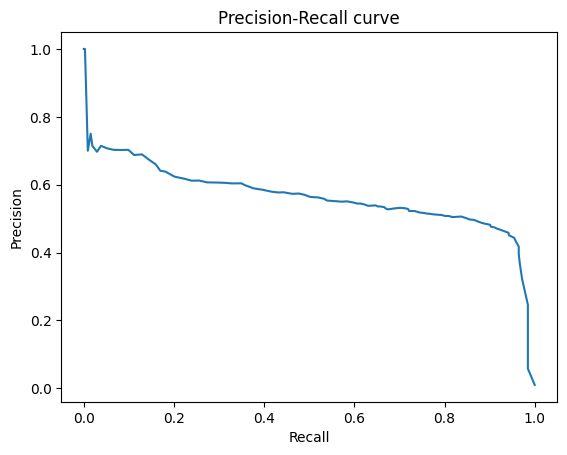

In [110]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.show()

In [111]:
test["score"] = y_proba

selection = (
    test.sort_values("score", ascending=False)
    .groupby("MONTH")
    .head(50)
)

/tmp/ipykernel_865/1155767924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["score"] = y_proba
